https://www.kaggle.com/datasets/sammy123/lower-back-pain-symptoms-dataset/data

# Conjunto de dados sobre sintomas de dor lombar

Coleta de dados físicos da coluna vertebral

# Sobre o conjunto de dados

310 observações, 13 atributos (12 preditores numéricos, 1 atributo de classe binária - sem dados demográficos)

A dor lombar pode ser causada por uma variedade de problemas em qualquer parte da complexa rede interconectada de músculos, nervos, ossos, discos ou tendões da coluna lombar. As causas típicas de dor lombar incluem:

As grandes raízes nervosas da região lombar que se estendem até as pernas podem ficar irritadas.
Os nervos menores que inervam a região lombar podem ficar irritados.
Os grandes músculos pares da região lombar (eretores da espinha) podem sofrer distensão.
Os ossos, ligamentos ou articulações podem ser danificados.
Um disco intervertebral pode estar degenerando.
Uma irritação ou problema em qualquer uma dessas estruturas pode causar dor lombar e/ou dor que irradia para outras partes do corpo. Muitos problemas na região lombar também causam espasmos musculares nas costas, que podem não parecer muito, mas podem causar dor intensa e incapacidade.

Embora a dor lombar seja extremamente comum, os sintomas e a intensidade dessa dor variam muito. Uma simples distensão muscular na região lombar pode ser tão excruciante a ponto de exigir uma visita ao pronto-socorro, enquanto uma hérnia de disco pode causar apenas um desconforto leve e intermitente.

Este conjunto de dados tem como objetivo identificar se uma pessoa é normal ou anormal, utilizando detalhes/dados físicos coletados da coluna vertebral.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('Dataset_spine.csv')

# EAD

In [2]:
print(df.head())
print(df.info())

        Col1       Col2       Col3       Col4        Col5       Col6  \
0  63.027817  22.552586  39.609117  40.475232   98.672917  -0.254400   
1  39.056951  10.060991  25.015378  28.995960  114.405425   4.564259   
2  68.832021  22.218482  50.092194  46.613539  105.985135  -3.530317   
3  69.297008  24.652878  44.311238  44.644130  101.868495  11.211523   
4  49.712859   9.652075  28.317406  40.060784  108.168725   7.918501   

       Col7     Col8     Col9     Col10      Col11    Col12 Class_att  \
0  0.744503  12.5661  14.5386  15.30468 -28.658501  43.5123  Abnormal   
1  0.415186  12.8874  17.5323  16.78486 -25.530607  16.1102  Abnormal   
2  0.474889  26.8343  17.4861  16.65897 -29.031888  19.2221  Abnormal   
3  0.369345  23.5603  12.7074  11.42447 -30.470246  18.8329  Abnormal   
4  0.543360  35.4940  15.9546   8.87237 -16.378376  24.9171  Abnormal   

                                         Unnamed: 13  
0                                                NaN  
1                 

In [3]:
df.isna().sum()

Col1             0
Col2             0
Col3             0
Col4             0
Col5             0
Col6             0
Col7             0
Col8             0
Col9             0
Col10            0
Col11            0
Col12            0
Class_att        0
Unnamed: 13    296
dtype: int64

In [4]:
#Limpeza
if 'Unnamed: 13' in df.columns:
    df = df.drop(columns=['Unnamed: 13'])

print(df.describe())

             Col1        Col2        Col3        Col4        Col5        Col6  \
count  310.000000  310.000000  310.000000  310.000000  310.000000  310.000000   
mean    60.496653   17.542822   51.930930   42.953831  117.920655   26.296694   
std     17.236520   10.008330   18.554064   13.423102   13.317377   37.559027   
min     26.147921   -6.554948   14.000000   13.366931   70.082575  -11.058179   
25%     46.430294   10.667069   37.000000   33.347122  110.709196    1.603727   
50%     58.691038   16.357689   49.562398   42.404912  118.268178   11.767934   
75%     72.877696   22.120395   63.000000   52.695888  125.467674   41.287352   
max    129.834041   49.431864  125.742385  121.429566  163.071041  418.543082   

             Col7        Col8        Col9       Col10       Col11       Col12  
count  310.000000  310.000000  310.000000  310.000000  310.000000  310.000000  
mean     0.472979   21.321526   13.064511   11.933317  -14.053139   25.645981  
std      0.285787    8.639423 

C:\Users\Usuário\AppData\Local\Temp\ipykernel_11288\3576418075.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Class_att', data=df, palette='viridis')


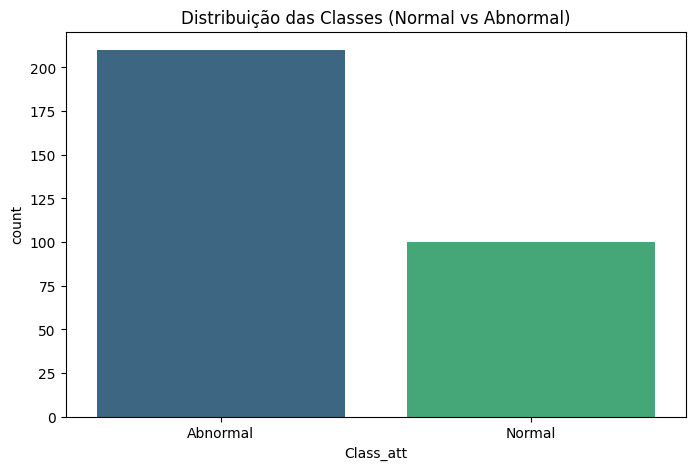

In [5]:
#Análise Univariada: A Variável Alvo
plt.figure(figsize=(8, 5))
sns.countplot(x='Class_att', data=df, palette='viridis')
plt.title('Distribuição das Classes (Normal vs Abnormal)')
plt.show()

C:\Users\Usuário\AppData\Local\Temp\ipykernel_11288\3200282768.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Class_att', y='Col1', data=df, palette='flare')


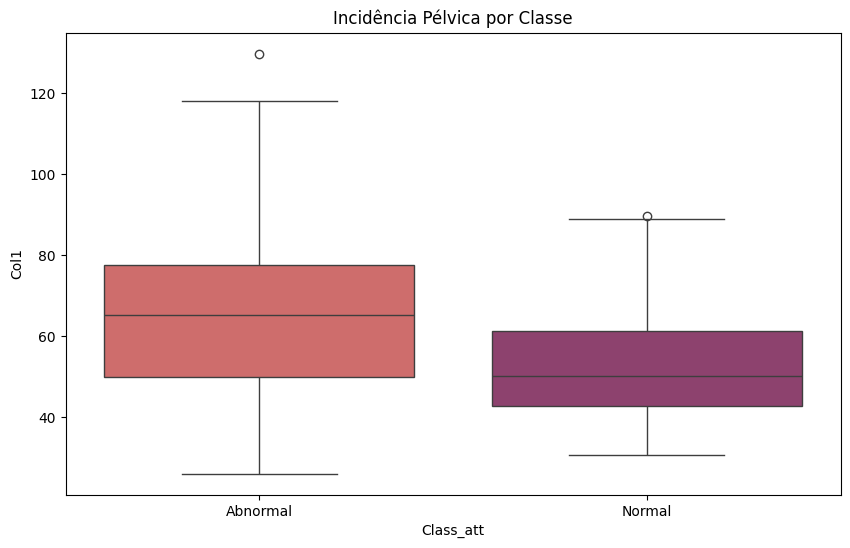

In [6]:
#Análise Bivariada: Relações entre Variáveis
#Exemplo: Comparando Col1 (Incidência Pélvica) entre as classes
plt.figure(figsize=(10, 6))
sns.boxplot(x='Class_att', y='Col1', data=df, palette='flare')
plt.title('Incidência Pélvica por Classe')
plt.show()

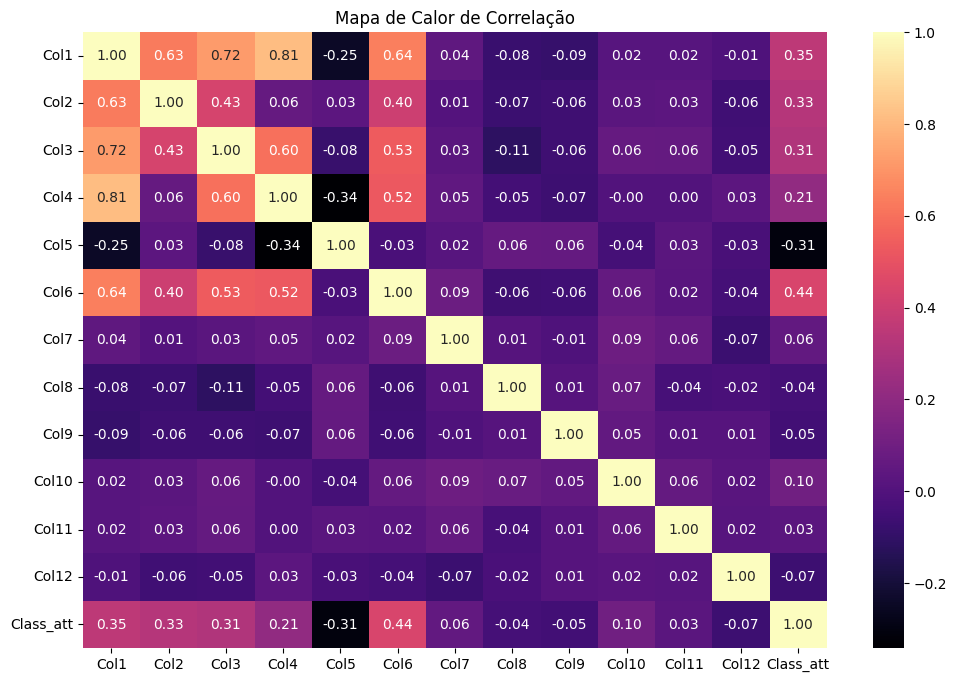

In [7]:
#Heatmap
df_numeric = df.copy()
df_numeric['Class_att'] = df_numeric['Class_att'].map({'Abnormal': 1, 'Normal': 0})

plt.figure(figsize=(12, 8))
sns.heatmap(df_numeric.corr(), annot=True, cmap='magma', fmt='.2f')
plt.title('Mapa de Calor de Correlação')
plt.show()

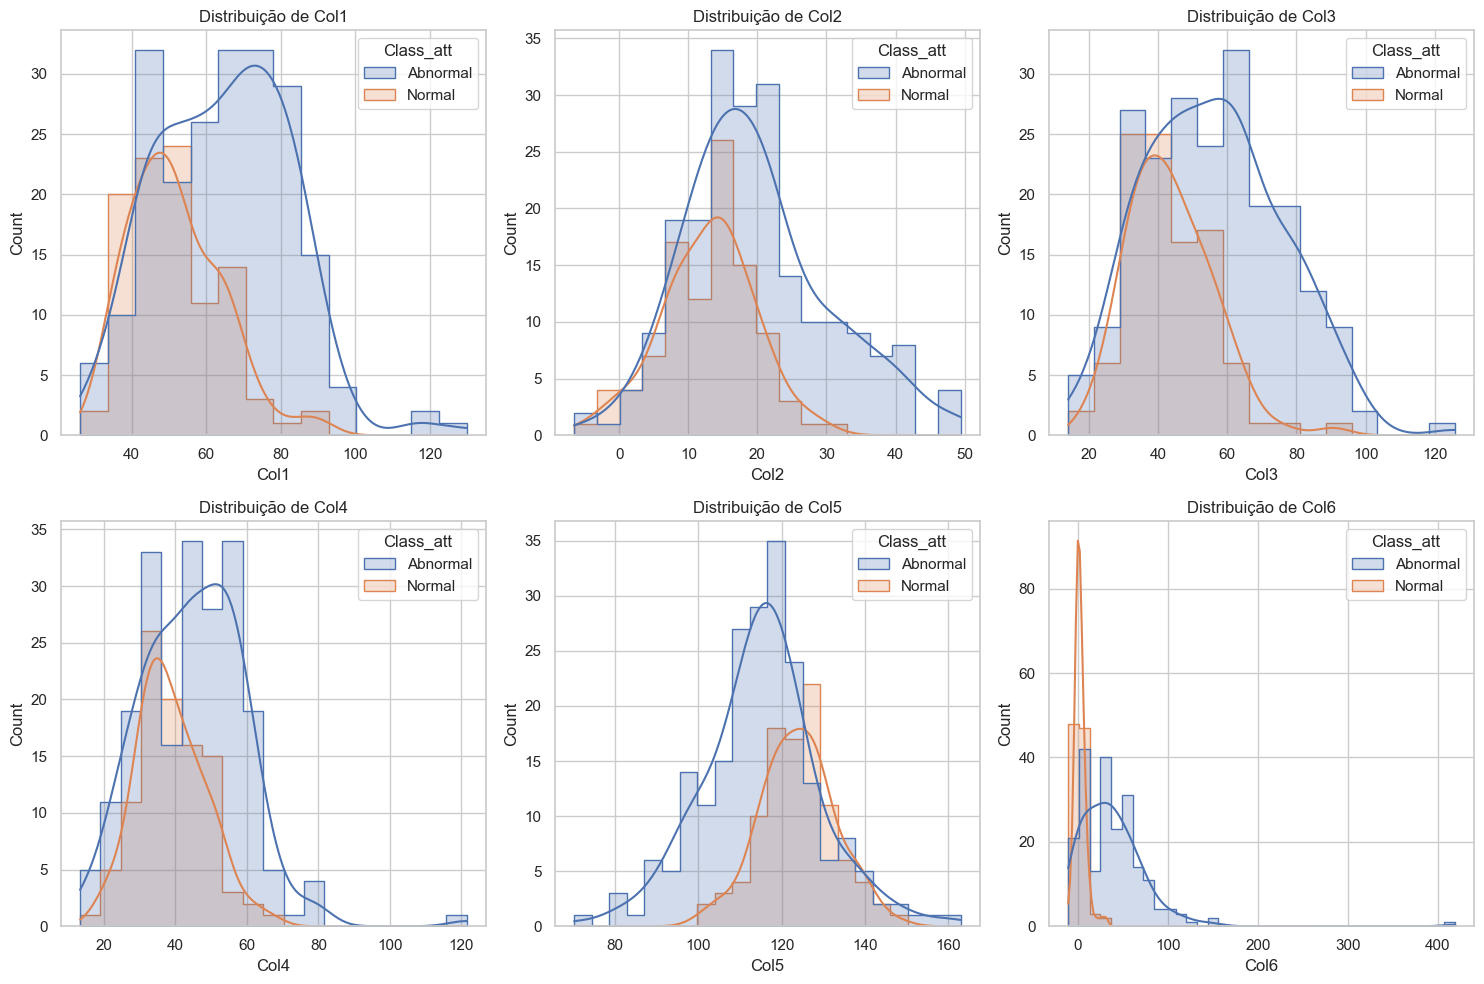

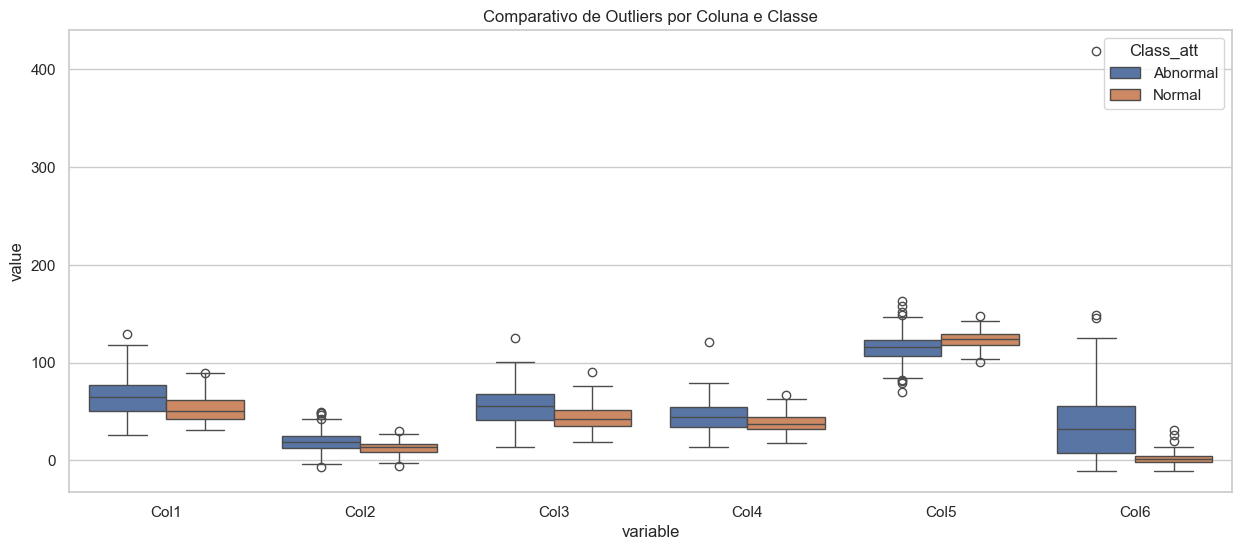

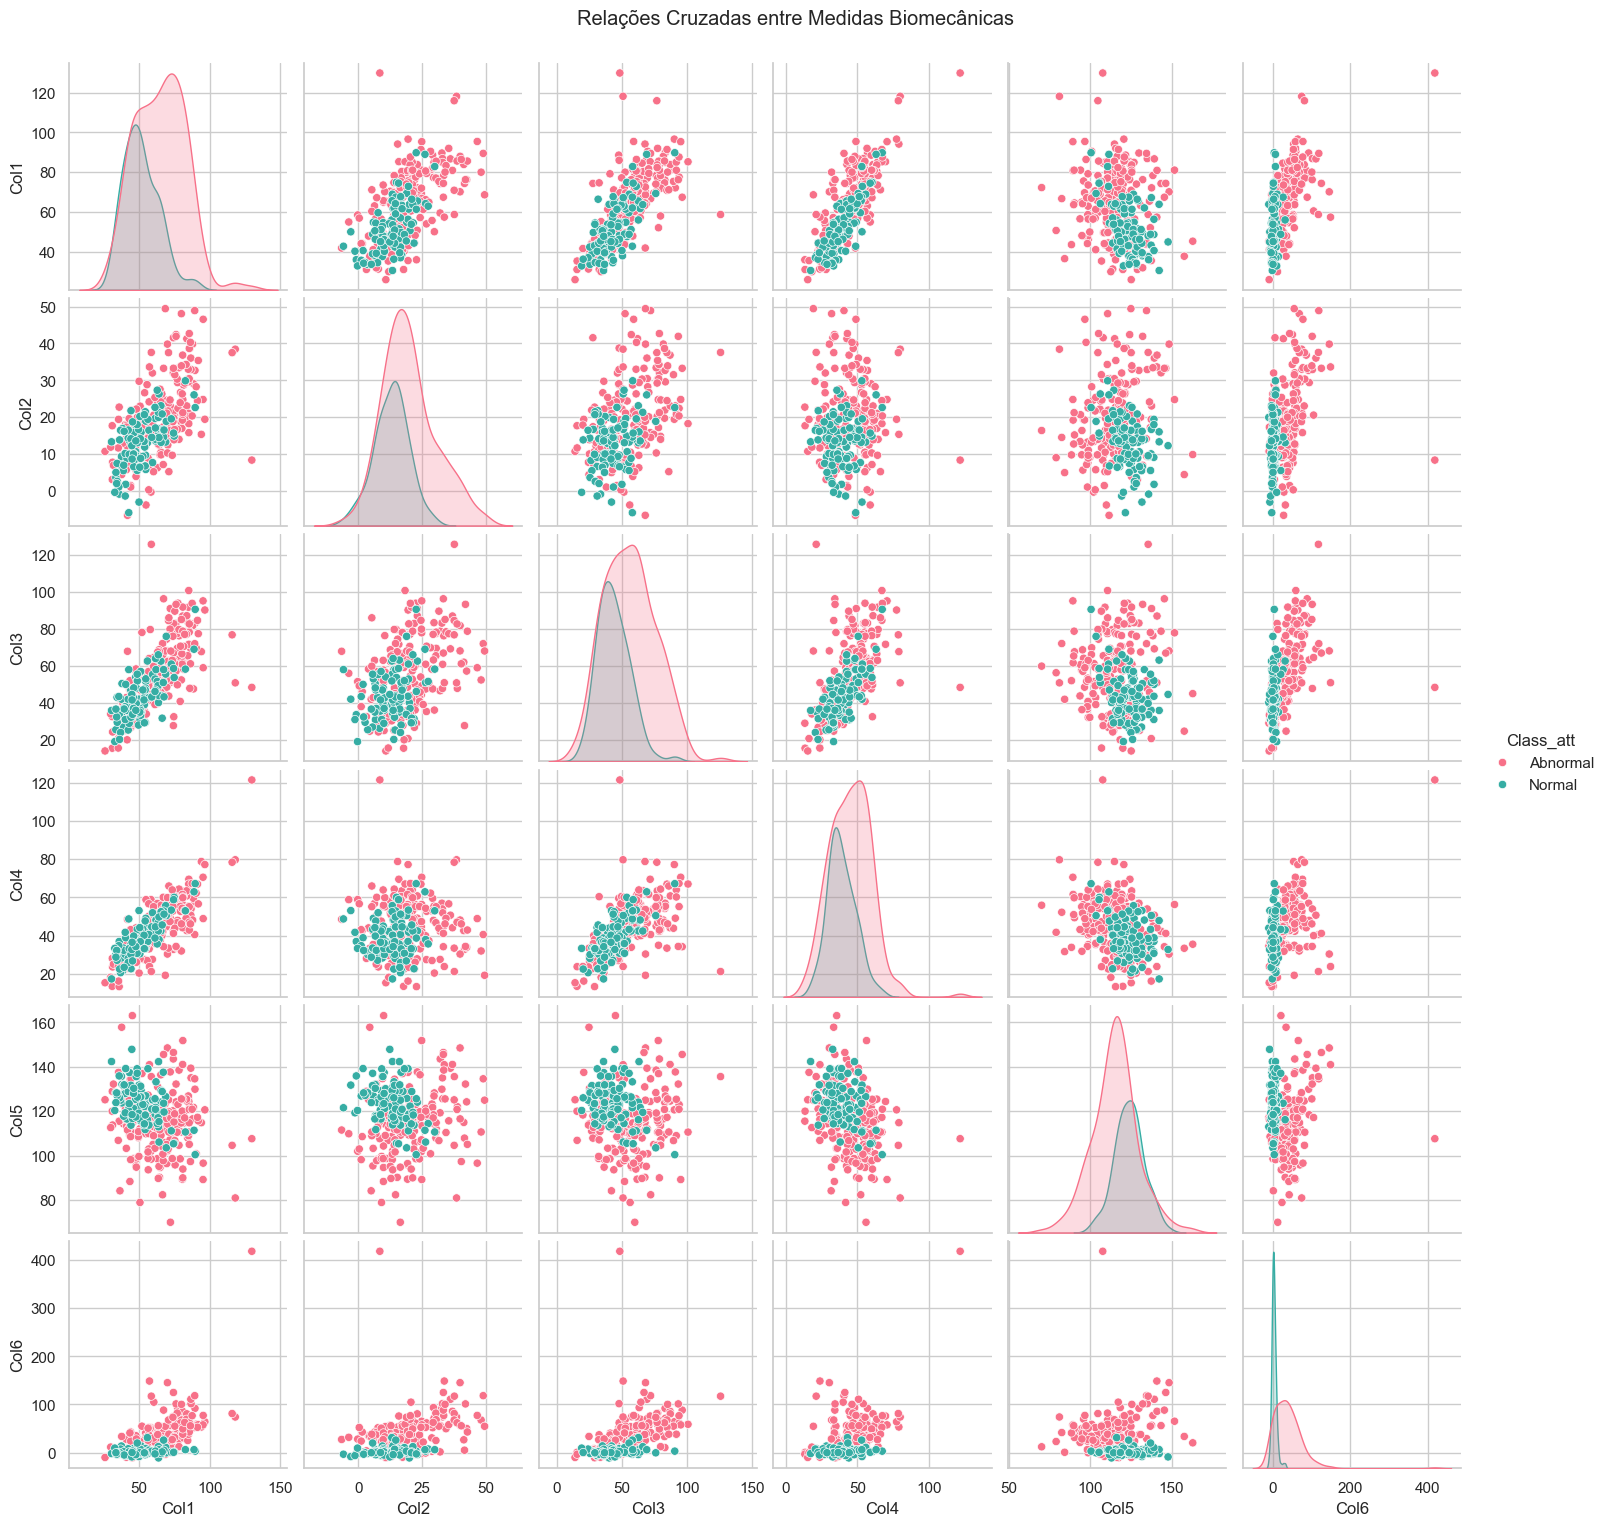

In [8]:
sns.set_theme(style="whitegrid")

if 'Unnamed: 13' in df.columns:
    df = df.drop(columns=['Unnamed: 13'])

cols_analise = ['Col1', 'Col2', 'Col3', 'Col4', 'Col5', 'Col6']

plt.figure(figsize=(15, 10))
for i, col in enumerate(cols_analise, 1):
    plt.subplot(2, 3, i)
    sns.histplot(data=df, x=col, hue='Class_att', kde=True, element="step")
    plt.title(f'Distribuição de {col}')

plt.tight_layout()
plt.show()

#Análise de Outliers (Boxplots)
plt.figure(figsize=(15, 6))
df_melted = df.melt(id_vars='Class_att', value_vars=cols_analise)
sns.boxplot(data=df_melted, x='variable', y='value', hue='Class_att')
plt.title('Comparativo de Outliers por Coluna e Classe')
plt.show()

#Relações Multivariadas (Pairplot)
sns.pairplot(df, vars=cols_analise, hue='Class_att', palette='husl', diag_kind='kde')
plt.suptitle('Relações Cruzadas entre Medidas Biomecânicas', y=1.02)
plt.show()

# ML

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix

#Transformar a variável alvo em numérica
df['Class_att'] = df['Class_att'].map({'Abnormal': 1, 'Normal': 0})

#Separar as features (X) do alvo (y)
X = df.drop('Class_att', axis=1)
y = df['Class_att']

#Dividir em Treino (70%) e Teste (30%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

#Normalização (Scaling)
#Importante: O modelo KNN se baseia em distância, então todas as colunas devem estar na mesma escala
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

#Criar e treinar o modelo
modelo = KNeighborsClassifier(n_neighbors=5)
modelo.fit(X_train, y_train)

#Fazer previsões
previsoes = modelo.predict(X_test)

#Relatório de Performance
print("--- Matriz de Confusão ---")
print(confusion_matrix(y_test, previsoes))
print("Relatório de Classificação")
print(classification_report(y_test, previsoes))

--- Matriz de Confusão ---
[[17  7]
 [12 57]]
Relatório de Classificação
              precision    recall  f1-score   support

           0       0.59      0.71      0.64        24
           1       0.89      0.83      0.86        69

    accuracy                           0.80        93
   macro avg       0.74      0.77      0.75        93
weighted avg       0.81      0.80      0.80        93



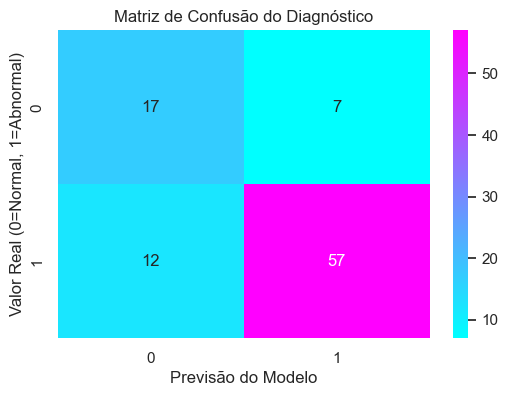

In [10]:
#Visualizando os Erros (Matriz de Confusão)
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, previsoes), annot=True, fmt='d', cmap='cool')
plt.xlabel('Previsão do Modelo')
plt.ylabel('Valor Real (0=Normal, 1=Abnormal)')
plt.title('Matriz de Confusão do Diagnóstico')
plt.show()

In [11]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

#Criar o modelo de Árvore de Decisão
modelo_tree = DecisionTreeClassifier(max_depth=4, random_state=42)
modelo_tree.fit(X_train, y_train)

previsoes_tree = modelo_tree.predict(X_test)

print("Relatório Árvore de Decisão")
print(classification_report(y_test, previsoes_tree))

Relatório Árvore de Decisão
              precision    recall  f1-score   support

           0       0.54      0.62      0.58        24
           1       0.86      0.81      0.84        69

    accuracy                           0.76        93
   macro avg       0.70      0.72      0.71        93
weighted avg       0.78      0.76      0.77        93



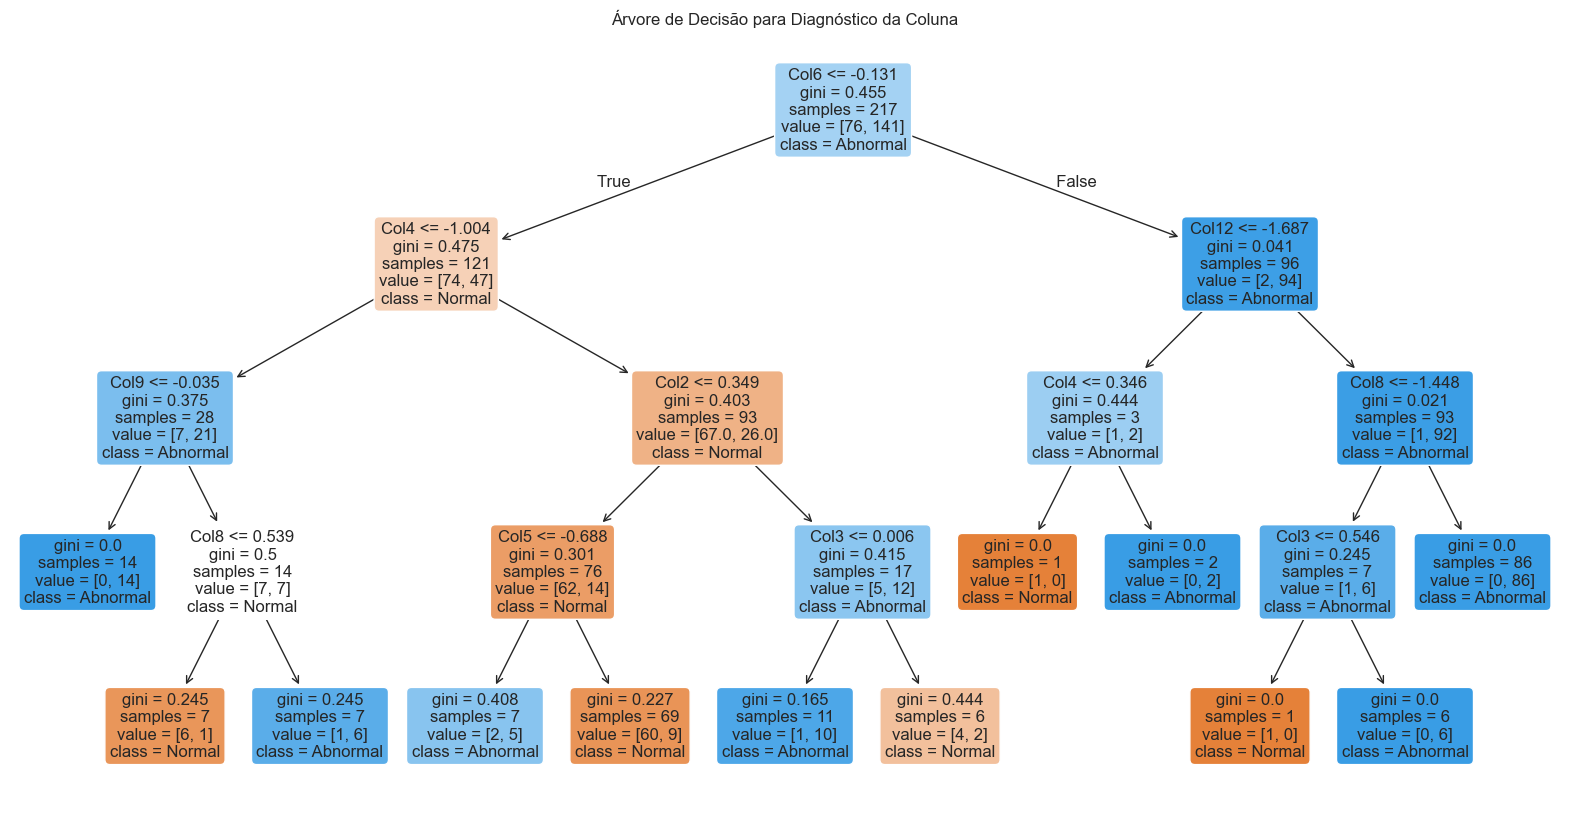

In [12]:
plt.figure(figsize=(20,10))
plot_tree(modelo_tree, 
          feature_names=X.columns, 
          class_names=['Normal', 'Abnormal'], 
          filled=True, 
          rounded=True, 
          fontsize=12)
plt.title("Árvore de Decisão para Diagnóstico da Coluna")
plt.show()

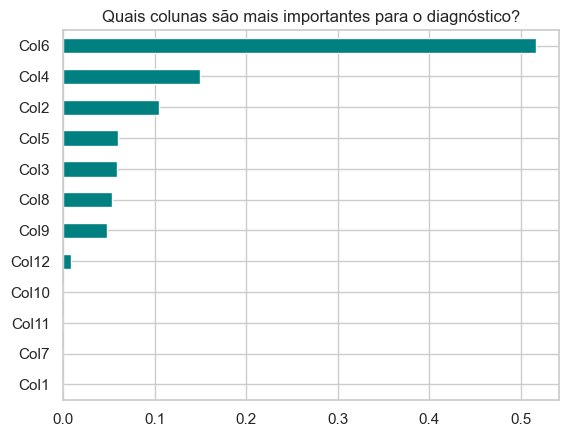

In [13]:
importancias = pd.Series(modelo_tree.feature_importances_, index=X.columns)
importancias.sort_values().plot(kind='barh', color='teal')
plt.title('Quais colunas são mais importantes para o diagnóstico?')
plt.show()

# Curva ROC

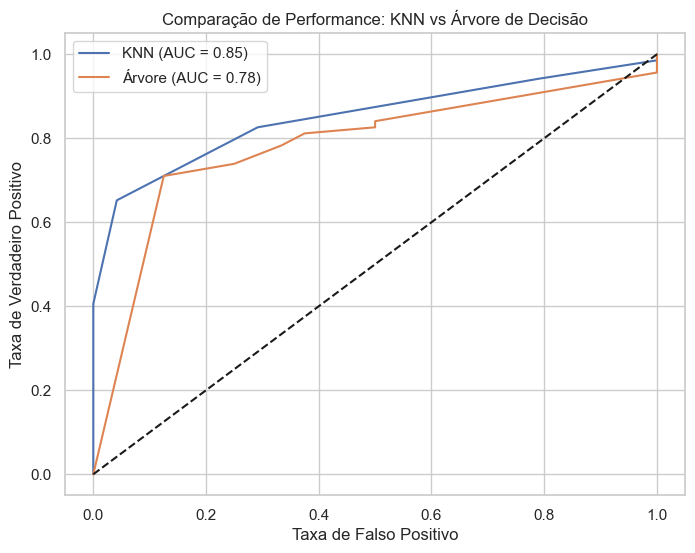

In [14]:
from sklearn.metrics import roc_curve, roc_auc_score

#Obter probabilidades (em vez de apenas 0 ou 1)
prob_knn = modelo.predict_proba(X_test)[:, 1]
prob_tree = modelo_tree.predict_proba(X_test)[:, 1]

#Calcular taxas
fpr_knn, tpr_knn, _ = roc_curve(y_test, prob_knn)
fpr_tree, tpr_tree, _ = roc_curve(y_test, prob_tree)

plt.figure(figsize=(8, 6))
plt.plot(fpr_knn, tpr_knn, label=f'KNN (AUC = {roc_auc_score(y_test, prob_knn):.2f})')
plt.plot(fpr_tree, tpr_tree, label=f'Árvore (AUC = {roc_auc_score(y_test, prob_tree):.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('Taxa de Falso Positivo')
plt.ylabel('Taxa de Verdadeiro Positivo')
plt.title('Comparação de Performance: KNN vs Árvore de Decisão')
plt.legend()
plt.show()

In [15]:
from sklearn.ensemble import RandomForestClassifier

#Criando a floresta com 100 árvores
modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42)
modelo_rf.fit(X_train, y_train)

previsoes_rf = modelo_rf.predict(X_test)

print("Relatório Random Forest")
print(classification_report(y_test, previsoes_rf))

Relatório Random Forest
              precision    recall  f1-score   support

           0       0.64      0.58      0.61        24
           1       0.86      0.88      0.87        69

    accuracy                           0.81        93
   macro avg       0.75      0.73      0.74        93
weighted avg       0.80      0.81      0.80        93



In [16]:
#Versão do Random Forest que dá mais peso para a classe "Normal" (que é mais rara)
modelo_rf_balanced = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
modelo_rf_balanced.fit(X_train, y_train)

previsoes_balanced = modelo_rf_balanced.predict(X_test)
print("Relatório RF Balanceado")
print(classification_report(y_test, previsoes_balanced))

Relatório RF Balanceado
              precision    recall  f1-score   support

           0       0.62      0.54      0.58        24
           1       0.85      0.88      0.87        69

    accuracy                           0.80        93
   macro avg       0.73      0.71      0.72        93
weighted avg       0.79      0.80      0.79        93



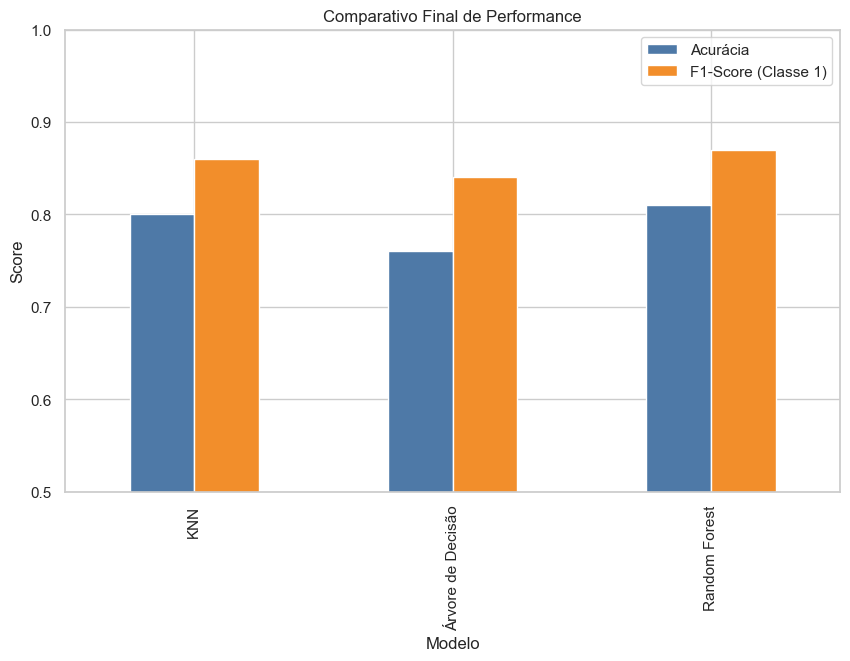

In [17]:
#Criando um resumo dos resultados
data = {
    'Modelo': ['KNN', 'Árvore de Decisão', 'Random Forest'],
    'Acurácia': [0.80, 0.76, 0.81],
    'F1-Score (Classe 1)': [0.86, 0.84, 0.87]
}

df_resumo = pd.DataFrame(data)
df_resumo.plot(x='Modelo', kind='bar', figsize=(10,6), color=['#4e79a7', '#f28e2b'])
plt.ylim(0.5, 1.0)
plt.title('Comparativo Final de Performance')
plt.ylabel('Score')
plt.show()

In [18]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

#Preparação rápida (como fizemos antes)
df = pd.read_csv('Dataset_spine.csv').drop(columns=['Unnamed: 13'], errors='ignore')
X = df.drop('Class_att', axis=1)
y = df['Class_att'].map({'Abnormal': 1, 'Normal': 0})

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

modelo_final = RandomForestClassifier(n_estimators=100, random_state=42)
modelo_final.fit(X_train_scaled, y_train)

#Função de Diagnóstico Direto
def diagnosticar_paciente(medidas):
    """
    Recebe uma lista com as 12 medidas e retorna o diagnóstico.
    """
    # Converte para o formato que o sklearn espera (1 linha, 12 colunas)
    dados_formatados = np.array([medidas])
    
    # Aplica a mesma escala usada no treino
    dados_normalizados = scaler.transform(dados_formatados)
    
    # Faz a predição
    pred = modelo_final.predict(dados_normalizados)
    prob = modelo_final.predict_proba(dados_normalizados)
    
    resultado = "Abnormal" if pred[0] == 1 else "Normal"
    confianca = prob[0][pred[0]] * 100
    
    return resultado, confianca

# --- TESTANDO AGORA ---
#Exemplo: Medidas de um paciente (Col1 até Col12)
exemplo_paciente = [63.02, 22.55, 39.60, 40.47, 98.67, -0.25, 0.74, 12.56, 14.53, 15.30, -28.65, 43.51]

diagnostico, certeza = diagnosticar_paciente(exemplo_paciente)

print(f"Resultado: {diagnostico}")
print(f"Confiança do Modelo: {certeza:.2f}%")

Resultado: Abnormal
Confiança do Modelo: 84.00%


c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


# Dashboard

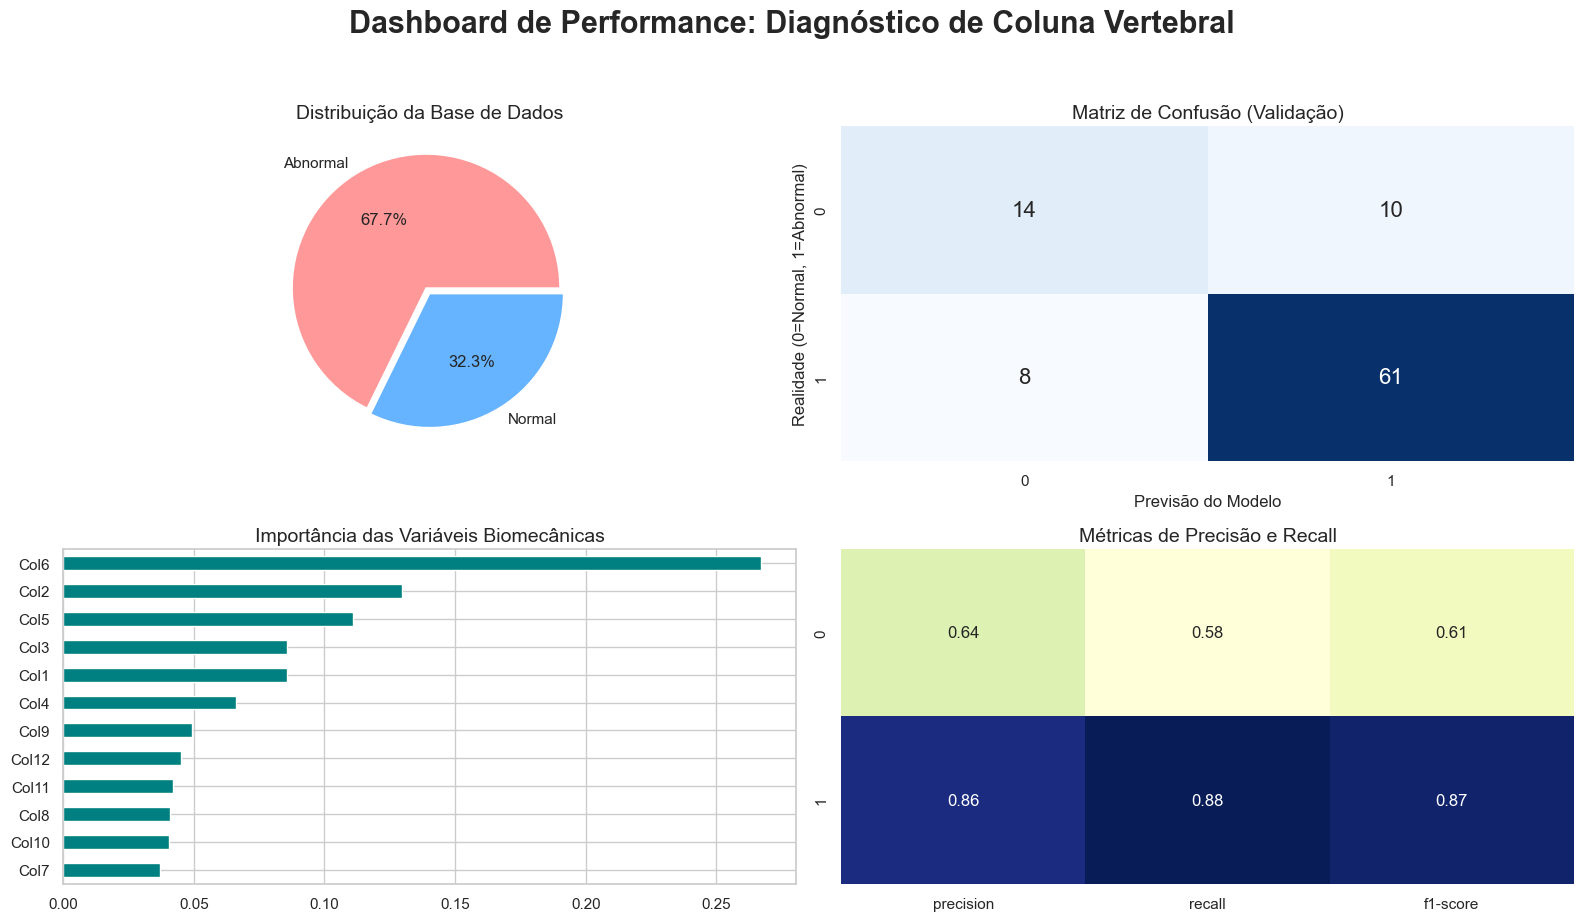

In [19]:
X = df.drop('Class_att', axis=1)
y = df['Class_att'].map({'Abnormal': 1, 'Normal': 0})
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

modelo = RandomForestClassifier(n_estimators=100, random_state=42)
modelo.fit(X_train, y_train)
y_pred = modelo.predict(X_test)

#CONFIGURAÇÃO DO DASHBOARD
fig = plt.figure(figsize=(16, 10))
fig.suptitle('Dashboard de Performance: Diagnóstico de Coluna Vertebral', fontsize=22, fontweight='bold', y=0.95)

#Gráfico 1: Distribuição de Classes (Proporção do Dataset)
plt.subplot(2, 2, 1)
df['Class_att'].value_counts().plot.pie(autopct='%1.1f%%', colors=['#ff9999','#66b3ff'], explode=(0.05, 0))
plt.title('Distribuição da Base de Dados', fontsize=14)
plt.ylabel('')

#Gráfico 2: Matriz de Confusão (Onde o modelo acerta/erra)
plt.subplot(2, 2, 2)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, annot_kws={"size": 16})
plt.title('Matriz de Confusão (Validação)', fontsize=14)
plt.xlabel('Previsão do Modelo')
plt.ylabel('Realidade (0=Normal, 1=Abnormal)')

#Gráfico 3: Importância das Features (O que mais impacta o diagnóstico)
plt.subplot(2, 2, 3)
importancias = pd.Series(modelo.feature_importances_, index=X.columns).sort_values()
importancias.plot(kind='barh', color='teal')
plt.title('Importância das Variáveis Biomecânicas', fontsize=14)

#Gráfico 4: Métricas de Precisão por Classe
plt.subplot(2, 2, 4)
report = classification_report(y_test, y_pred, output_dict=True)
metricas = pd.DataFrame(report).transpose().iloc[:2, :3] # Foca apenas em Precision, Recall, F1
sns.heatmap(metricas, annot=True, cmap='YlGnBu', cbar=False)
plt.title('Métricas de Precisão e Recall', fontsize=14)

plt.tight_layout(rect=[0, 0.03, 1, 0.92])
plt.show()

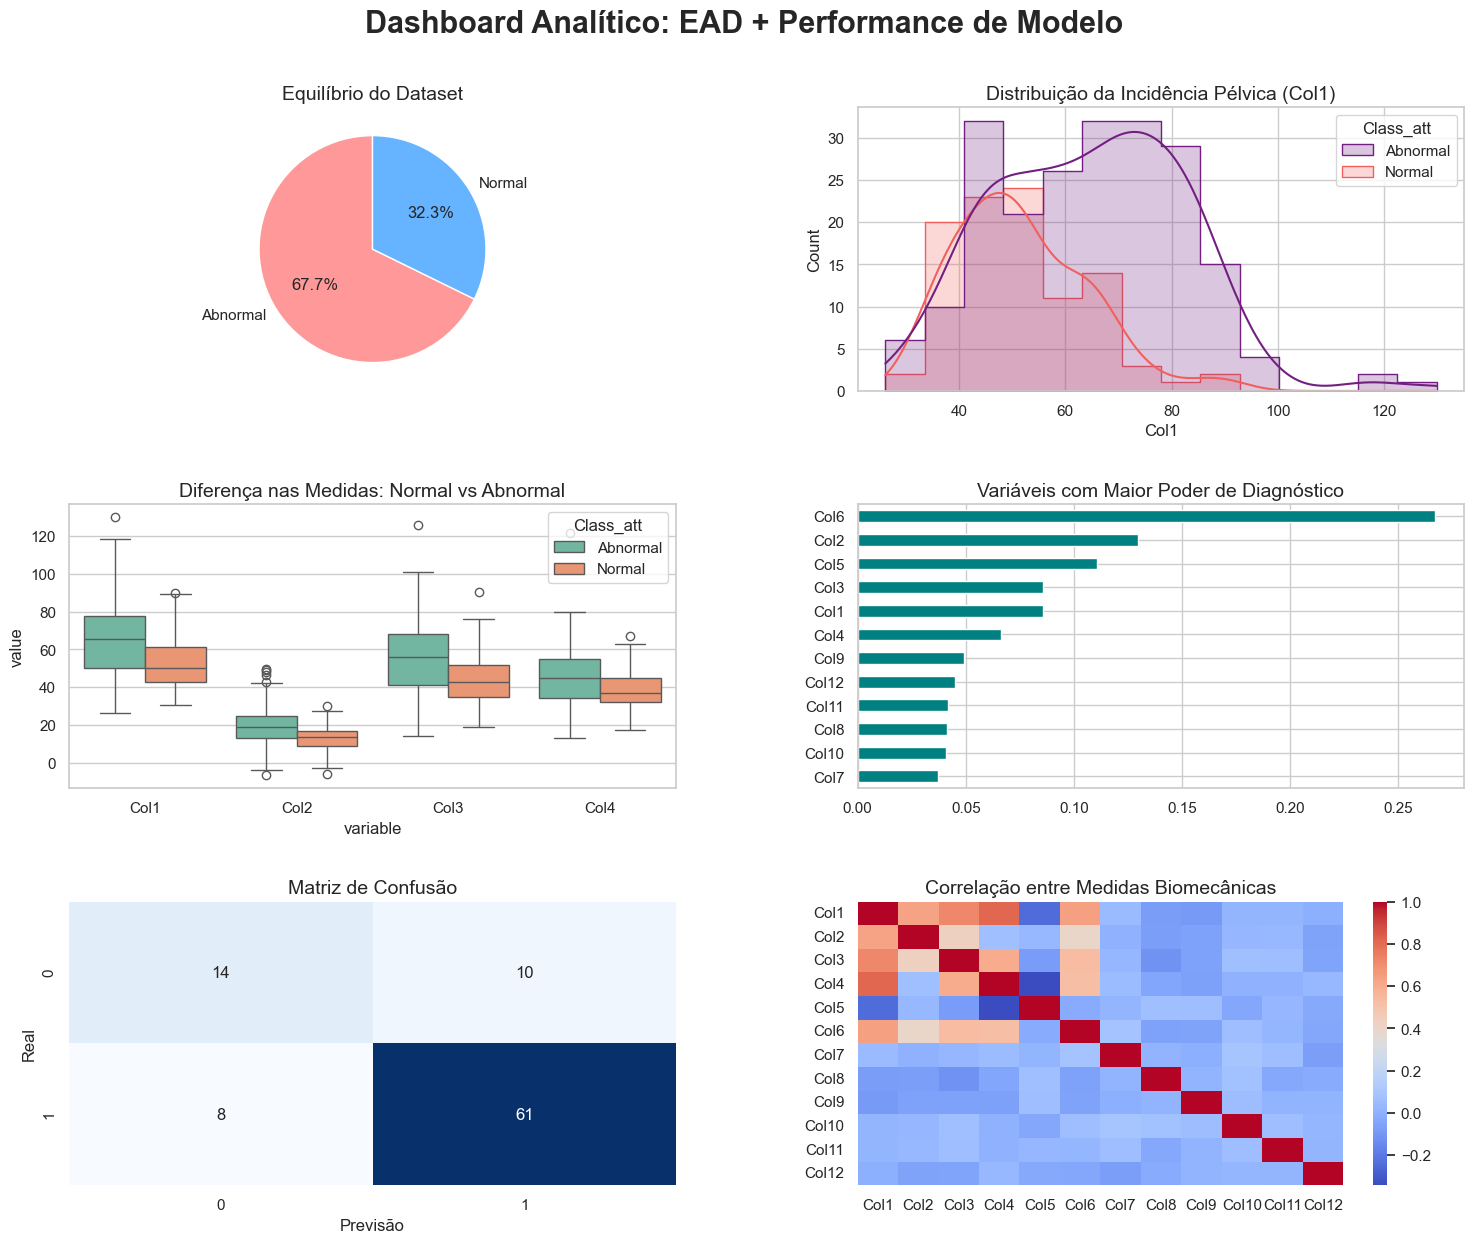

In [ ]:
X = df.drop('Class_att', axis=1)
y = df['Class_att'].map({'Abnormal': 1, 'Normal': 0})
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

modelo = RandomForestClassifier(n_estimators=100, random_state=42)
modelo.fit(X_train, y_train)

#CONFIGURAÇÃO DO DASHBOARD EXPANDIDO
fig = plt.figure(figsize=(18, 14))
plt.subplots_adjust(hspace=0.4, wspace=0.3)
fig.suptitle('Dashboard Analítico: EAD + Performance de Modelo', fontsize=22, fontweight='bold', y=0.95)

#Distribuição das Classes (Pie Chart)
plt.subplot(3, 2, 1)
df['Class_att'].value_counts().plot.pie(autopct='%1.1f%%', colors=['#ff9999','#66b3ff'], startangle=90)
plt.title('Equilíbrio do Dataset', fontsize=14)
plt.ylabel('')

#Distribuição Biomecânica (Histograma de uma coluna chave: Col1)
plt.subplot(3, 2, 2)
sns.histplot(data=df, x='Col1', hue='Class_att', kde=True, palette='magma', element="step")
plt.title('Distribuição da Incidência Pélvica (Col1)', fontsize=14)

#Comparativo de Medidas (Boxplot das principais variáveis)
plt.subplot(3, 2, 3)
df_melt = df.melt(id_vars='Class_att', value_vars=['Col1', 'Col2', 'Col3', 'Col4'])
sns.boxplot(data=df_melt, x='variable', y='value', hue='Class_att', palette='Set2')
plt.title('Diferença nas Medidas: Normal vs Abnormal', fontsize=14)

#Importância das Features (O que o modelo prioriza)
plt.subplot(3, 2, 4)
importancias = pd.Series(modelo.feature_importances_, index=X.columns).sort_values()
importancias.plot(kind='barh', color='teal')
plt.title('Variáveis com Maior Poder de Diagnóstico', fontsize=14)

#Matriz de Confusão
plt.subplot(3, 2, 5)
y_pred = modelo.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Matriz de Confusão', fontsize=14)
plt.xlabel('Previsão')
plt.ylabel('Real')

#Correlação de Medidas (Heatmap)
plt.subplot(3, 2, 6)
sns.heatmap(X.corr(), cmap='coolwarm', annot=False) # Annot=False para não poluir
plt.title('Correlação entre Medidas Biomecânicas', fontsize=14)

plt.show()

# Conclusão

A biomecânica da coluna segue padrões matemáticos claros. O uso de Machine Learning aqui não substitui o médico, mas serve como um "filtro inteligente" que consegue separar 8 de cada 10 pacientes corretamente apenas analisando medidas angulares.
Pacientes na classe "Abnormal" apresentam valores significativamente mais altos e maior variabilidade nesta medida; Col1 (Incidência Pélvica), Col6 (Spondylolisthesis) e Col4 (Inclinação Sacral).

# **Nathália Sorg**